## Day 5 — [프로젝트 1] 정형 데이터 예측 서비스

### 1. 프로젝트 개요

- 본 프로젝트는 캘리포니아 주택 가격 데이터를 기반으로 회귀 모델을 학습하고,
- 이를 FastAPI를 통해 API 형태로 배포한 뒤 Streamlit을 이용해 사용자 인터페이스까지 연결하는 것이다.
- 모델 학습부터 저장, API 서버 구축, 입력 검증, 예측 결과 반환, 프론트엔드 연동까지 전체 모델 서빙 파이프라인을 구현하였다.

### 2. 목차
- step 0 이전 작업 확인
- step 1 모델 파일 생성
- step 2 모델 학습 및 저장, Predictor 클래스 구현 및 추론
- step 3 FastAPI 서버 구축 및 테스트
- step 4 Streamlit 실행
- step 5 통합테스트 및 디버깅

### 3. 회고
- 5일간의 모델 배포 기초 연습은 막연한 불안과 두려움을 떨치는 계기가 되었다.
- RESTful API, FastAPI를 어떻게 준비해야할지 막연하고, 막막했는데 퍼실님이 잘 정리해 주신 노드를 보고 자신감을 얻었다.
- 지난 3개월간 개인적인 업무와 수업 준비을 따라가는 과정에서 과로로 피로가 누적되어, 한숨 돌리는 계기가 되었다.
- 선호님의 Backend 개발자의 경험이 이번 미션에 큰 도움이 되었다.
- 주말에 그동안 진행된 내용을 다시 정리하여 AI 엔지니어로 당당하게 업무를 진행할 수 있는 계기가 되도록 노력하겠다.

### 4. 산출물
---
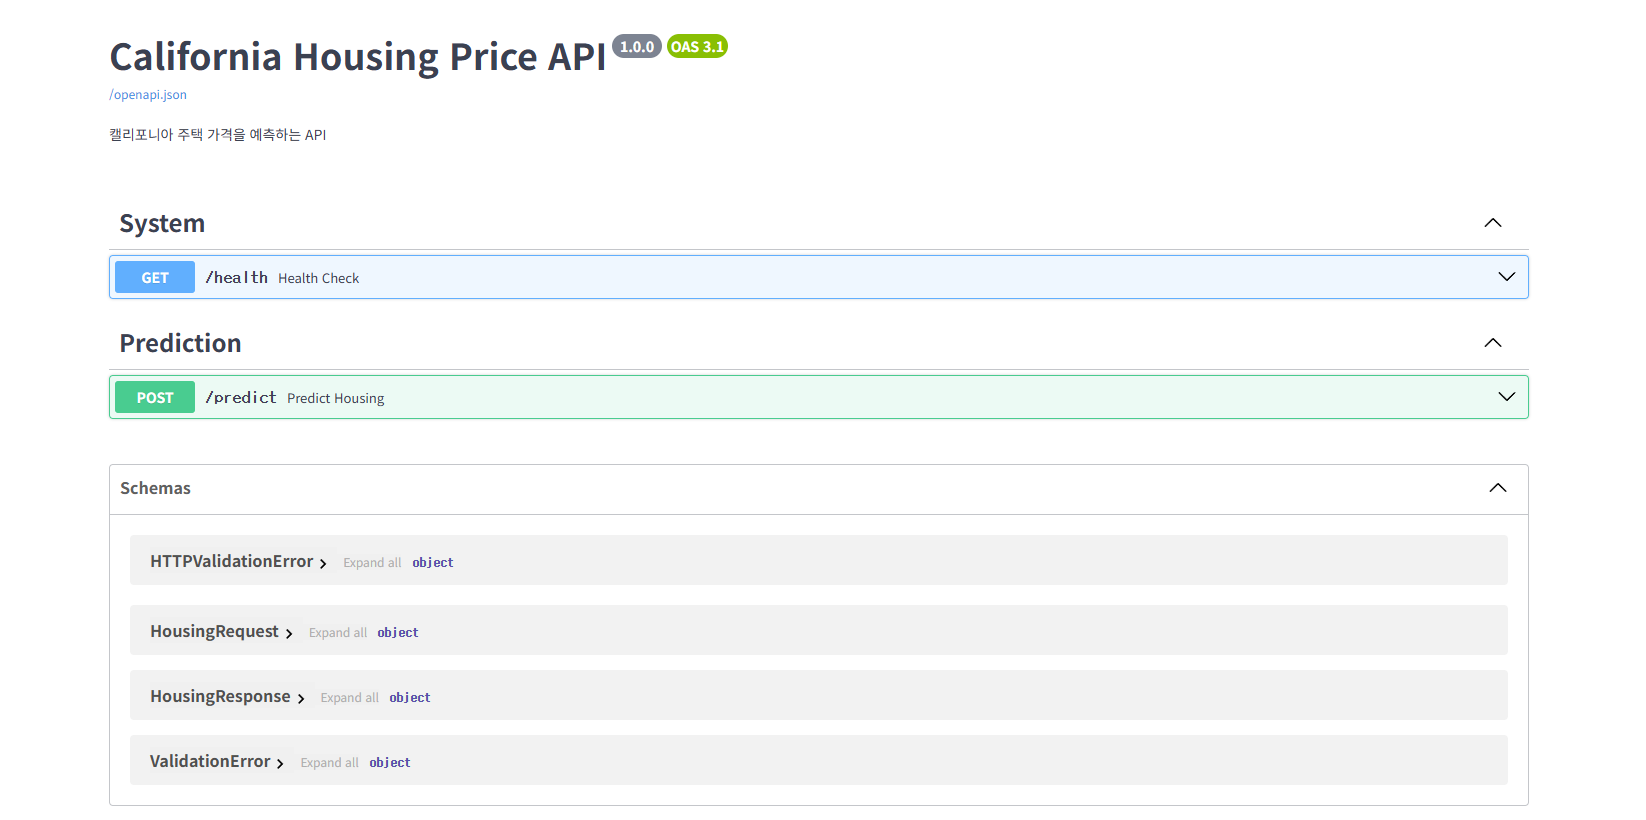
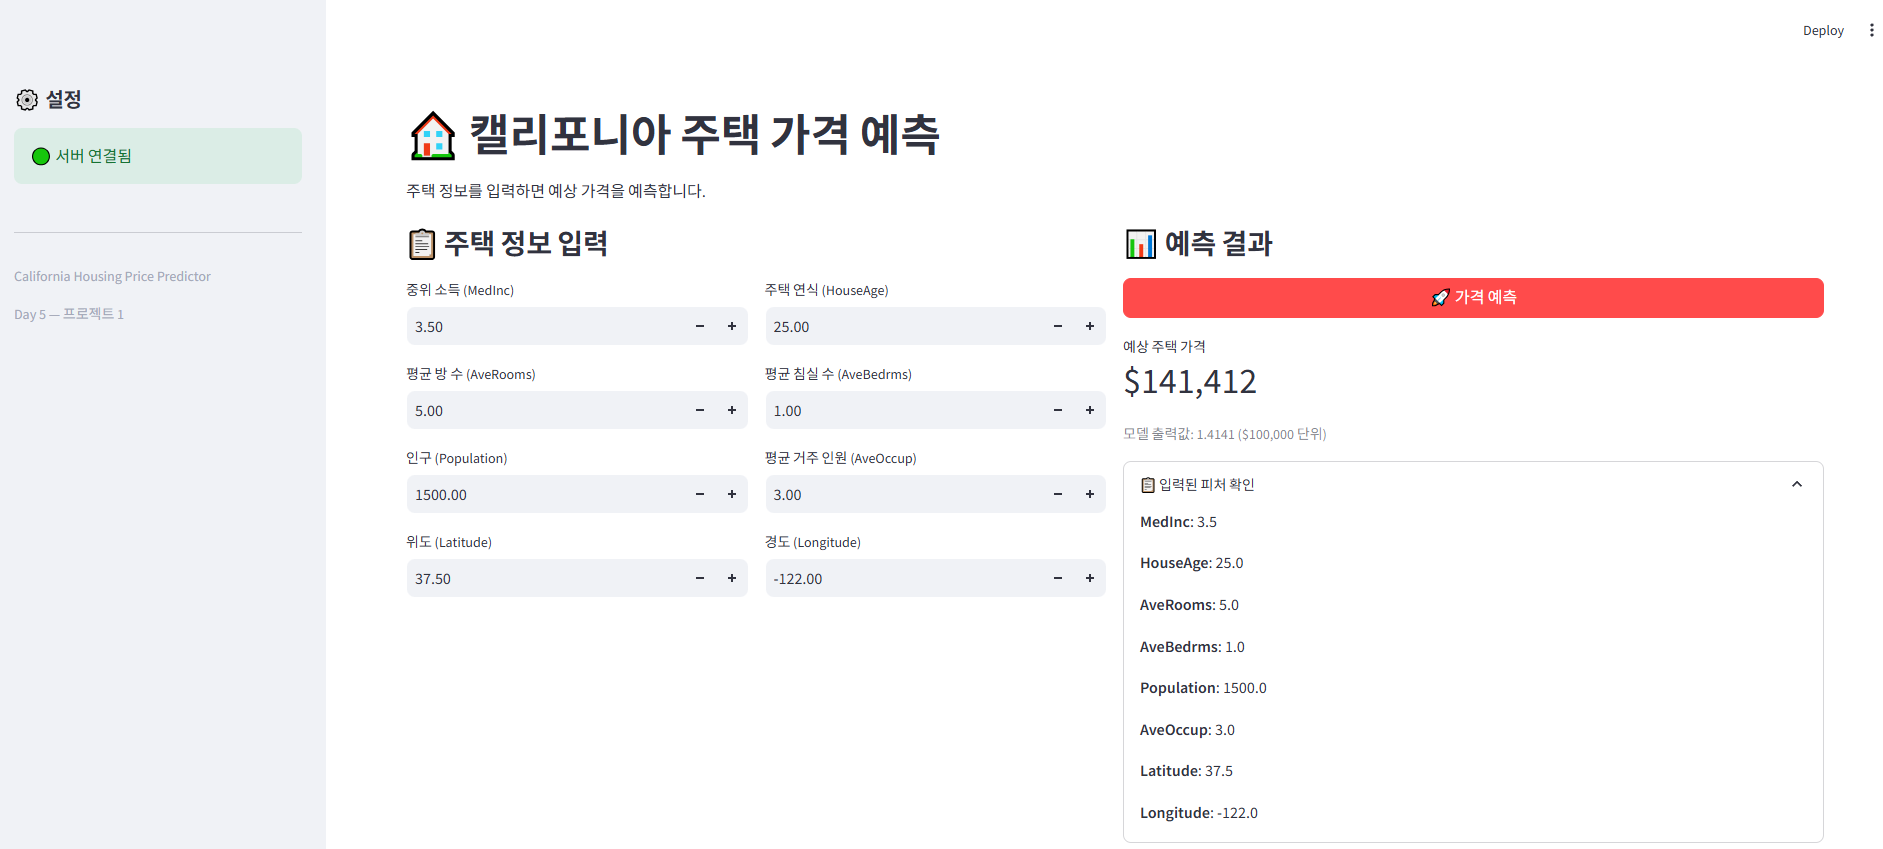
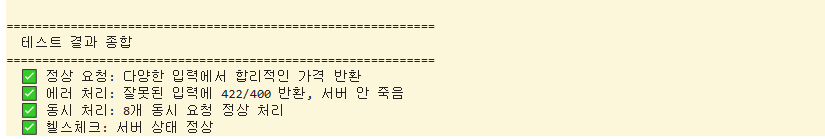
---

### STEP 0 이전 작업 확인

In [1]:
# ============================================================
# [STEP 0] Day 1, Day3 폴더 및 파일 확인
# - 폴더 확인
# - %%writefile app/logger_config.py
# - %%writefile app/error_handlers.py
# - %%writefile app/middleware.py
# ============================================================

from pathlib import Path

Path("app").mkdir(exist_ok=True)
Path("models").mkdir(exist_ok=True)
Path("frontend").mkdir(exist_ok=True)

print("기본 폴더 생성 완료")
print("- app/")
print("- models/")
print("- frontend/")

기본 폴더 생성 완료
- app/
- models/
- frontend/


In [1]:
%%writefile app/logger_config.py
"""
Day 3 - 로깅 설정 파일 확인
"""
import logging
import sys


def setup_logger(name: str = "ml_api", level: str = "INFO") -> logging.Logger:
    """콘솔 로거를 설정합니다."""
    logger = logging.getLogger(name)
    logger.setLevel(getattr(logging, level))

    if logger.handlers:
        return logger

    console_handler = logging.StreamHandler(sys.stdout)
    console_handler.setLevel(logging.DEBUG)

    formatter = logging.Formatter(
        fmt="%(asctime)s %(levelname)-8s [%(name)s] %(message)s",
        datefmt="%Y-%m-%d %H:%M:%S",
    )
    console_handler.setFormatter(formatter)
    logger.addHandler(console_handler)

    return logger

Overwriting app/logger_config.py


In [3]:
%%writefile app/error_handlers.py
"""
Day 3 - 글로벌 에러 핸들러 확인
"""
import traceback
import logging

from fastapi import FastAPI, Request
from fastapi.responses import JSONResponse

logger = logging.getLogger("ml_api")


def register_error_handlers(app: FastAPI):
    """FastAPI 앱에 글로벌 에러 핸들러를 등록합니다."""

    @app.exception_handler(Exception)
    async def general_error_handler(request: Request, exc: Exception):
        """모든 예외를 잡아서 안전한 응답을 반환합니다."""
        logger.error(
            f"에러 발생: {type(exc).__name__}: {exc}\n"
            f"경로: {request.method} {request.url}\n"
            f"스택 트레이스:\n{traceback.format_exc()}"
        )
        return JSONResponse(
            status_code=500,
            content={
                "success": False,
                "error": "서버 내부 오류가 발생했습니다.",
            }
            # ⚠️ 클라이언트에게는 상세 정보를 노출하지 않습니다.
            # 상세 정보는 서버 로그에만 기록됩니다.
        )

Overwriting app/error_handlers.py


In [5]:
%%writefile app/middleware.py
"""
Day 3 - 요청/응답 로깅 미들웨어 확인
"""
import time
import logging
from fastapi import Request
from starlette.middleware.base import BaseHTTPMiddleware

logger = logging.getLogger("ml_api")


class RequestLoggingMiddleware(BaseHTTPMiddleware):
    async def dispatch(self, request: Request, call_next):
        start_time = time.time()
        response = await call_next(request)
        duration = round(time.time() - start_time, 3)

        log_message = (
            f"{request.method} {request.url.path} "
            f"→ {response.status_code} "
            f"({duration}s)"
        )

        if response.status_code >= 500:
            logger.error(log_message)
        elif response.status_code >= 400:
            logger.warning(log_message)
        else:
            logger.info(log_message)

        response.headers["X-Process-Time"] = str(duration)
        return response

Overwriting app/middleware.py


In [9]:
# ============================================================
# [STEP 0] 생성된 공통 파일 확인
# ============================================================

from pathlib import Path

files_to_check = [
    "app/logger_config.py",
    "app/error_handlers.py",
    "app/middleware.py",
]

print("생성 파일 확인")
for file_path in files_to_check:
    exists = Path(file_path).exists()
    print(f"{file_path}: {'OK' if exists else '없음'}")

생성 파일 확인
app/logger_config.py: OK
app/error_handlers.py: OK
app/middleware.py: OK


In [7]:
# ============================================================
# [STEP 0] 공통 모듈 import 테스트
# - Day 5의 housing_api.py에서 import할 파일들이 정상인지 확인합니다.
# ============================================================

from app.logger_config import setup_logger
from app.error_handlers import register_error_handlers
from app.middleware import RequestLoggingMiddleware

logger = setup_logger()

print("import 테스트 완료")
print("setup_logger:", setup_logger)
print("register_error_handlers:", register_error_handlers)
print("RequestLoggingMiddleware:", RequestLoggingMiddleware)

import 테스트 완료
setup_logger: <function setup_logger at 0x0000012D45D29BC0>
register_error_handlers: <function register_error_handlers at 0x0000012D45D2A020>
RequestLoggingMiddleware: <class 'app.middleware.RequestLoggingMiddleware'>


In [9]:
%%writefile app/test_api.py
"""
공통 모듈 연결 테스트용 간단한 FastAPI 앱
"""
from fastapi import FastAPI
from fastapi.responses import JSONResponse

from app.logger_config import setup_logger
from app.error_handlers import register_error_handlers
from app.middleware import RequestLoggingMiddleware

logger = setup_logger()

app = FastAPI(title="Common Module Test API")

app.add_middleware(RequestLoggingMiddleware)
register_error_handlers(app)


@app.get("/")
def root():
    logger.info("루트 엔드포인트 호출")
    return {"message": "test api is running"}


@app.get("/health")
def health():
    return {"status": "ok"}


@app.get("/error")
def error_test():
    raise ValueError("에러 핸들러 테스트용 예외")

Overwriting app/test_api.py


### step 1 모델 파일 생성

In [1]:
# ============================================================
# [STEP 1] 모델 파일 생성
# - app/housing_model.py
# - app/housing_schemas.py
# - app/housing_api.py
# - frontend/app_housing.py
# ============================================================

In [3]:
%%writefile app/housing_model.py
"""
Day 5 - 주택 가격 예측 모델 정의 + 추론 함수
"""
import json
import torch
import torch.nn as nn
import numpy as np


class HousingModel(nn.Module):
    """캘리포니아 주택 가격 예측 모델"""
    def __init__(self, input_dim=8):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        return self.network(x)


class HousingPredictor:
    """모델 로드 + 전처리 + 추론을 캡슐화한 클래스"""

    def __init__(self, model_path: str, preprocessing_path: str):
        # 전처리 파라미터 로드
        with open(preprocessing_path, "r", encoding="utf-8") as f:
            params = json.load(f)

        self.mean = np.array(params["mean"], dtype=np.float32)
        self.std = np.array(params["std"], dtype=np.float32)
        self.feature_names = params["feature_names"]

        # 0으로 나누는 문제 방지
        self.std = np.where(self.std == 0, 1.0, self.std)

        # 모델 로드
        self.model = HousingModel(input_dim=len(self.feature_names))
        self.model.load_state_dict(
            torch.load(model_path, map_location="cpu", weights_only=True)
        )
        self.model.eval()

    def predict(self, features: dict) -> dict:
        """
        피처 딕셔너리를 받아 가격을 예측합니다.

        Args:
            features: {"MedInc": 3.5, "HouseAge": 25, ...}
        Returns:
            {"predicted_price": 2.35, "predicted_price_usd": 235000}
        """
        # 피처를 올바른 순서로 배열
        values = [features[name] for name in self.feature_names]

        # 정규화
        values = np.array(values, dtype=np.float32)
        normalized = (values - self.mean) / self.std

        # 추론
        input_tensor = torch.FloatTensor(normalized).unsqueeze(0)  # (1, 8)
        with torch.no_grad():
            output = self.model(input_tensor)

        price = output.item()
        price = max(price, 0.0)  # 음수 방지

        return {
            "predicted_price": round(price, 4),
            "predicted_price_usd": int(price * 100000),
        }

Overwriting app/housing_model.py


In [5]:
%%writefile app/housing_schemas.py
"""
Day 5 - 주택 가격 예측 API 스키마
"""
from pydantic import BaseModel, Field


class HousingRequest(BaseModel):
    """주택 가격 예측 요청"""
    MedInc: float = Field(..., gt=0, description="중위 소득")
    HouseAge: float = Field(..., ge=0, le=100, description="주택 연식 (년)")
    AveRooms: float = Field(..., gt=0, description="평균 방 수")
    AveBedrms: float = Field(..., gt=0, description="평균 침실 수")
    Population: float = Field(..., gt=0, description="인구")
    AveOccup: float = Field(..., gt=0, description="평균 거주 인원")
    Latitude: float = Field(..., ge=32, le=42, description="위도 (캘리포니아 범위)")
    Longitude: float = Field(..., ge=-125, le=-114, description="경도 (캘리포니아 범위)")

    model_config = {
        "json_schema_extra": {
            "examples": [
                {
                    "MedInc": 3.5,
                    "HouseAge": 25.0,
                    "AveRooms": 5.0,
                    "AveBedrms": 1.0,
                    "Population": 1500.0,
                    "AveOccup": 3.0,
                    "Latitude": 37.5,
                    "Longitude": -122.0,
                }
            ]
        }
    }


class HousingResponse(BaseModel):
    """주택 가격 예측 응답"""
    success: bool = Field(description="요청 처리 성공 여부")
    predicted_price: float = Field(description="예측 가격 ($100,000 단위)")
    predicted_price_usd: int = Field(description="예측 가격 (USD)")
    input_features: dict = Field(description="입력된 피처 값")

Overwriting app/housing_schemas.py


In [7]:
%%writefile app/housing_api.py
"""
Day 5 - 주택 가격 예측 FastAPI 서버
"""
import asyncio
from concurrent.futures import ThreadPoolExecutor

from fastapi import FastAPI, HTTPException

from app.housing_schemas import HousingRequest, HousingResponse
from app.housing_model import HousingPredictor
from app.logger_config import setup_logger
from app.error_handlers import register_error_handlers
from app.middleware import RequestLoggingMiddleware


# ===== 설정 =====
logger = setup_logger("housing_api")

app = FastAPI(
    title="California Housing Price API",
    description="캘리포니아 주택 가격을 예측하는 API",
    version="1.0.0",
)

app.add_middleware(RequestLoggingMiddleware)
register_error_handlers(app)

# 추론 전용 스레드풀
inference_executor = ThreadPoolExecutor(max_workers=4, thread_name_prefix="housing")

# ===== 모델 로드 =====
MODEL_PATH = "models/housing_model.pth"
PREPROCESS_PATH = "models/housing_preprocessing.json"
predictor = None


@app.on_event("startup")
async def startup():
    global predictor
    logger.info("주택 가격 모델 로드 중...")
    predictor = HousingPredictor(MODEL_PATH, PREPROCESS_PATH)
    logger.info("모델 로드 완료")


# ===== 엔드포인트 =====

@app.get("/health", tags=["System"])
async def health_check():
    return {
        "status": "healthy" if predictor is not None else "loading",
        "model": "California Housing",
    }


@app.post("/predict", response_model=HousingResponse, tags=["Prediction"])
async def predict_housing(request: HousingRequest):
    """주택 정보를 받아 가격을 예측합니다."""
    if predictor is None:
        raise HTTPException(status_code=503, detail="모델이 아직 로드되지 않았습니다.")

    # 요청 데이터를 딕셔너리로 변환
    features = request.model_dump()

    try:
        # 추론 (별도 스레드에서 실행)
        loop = asyncio.get_event_loop()
        result = await loop.run_in_executor(
            inference_executor,
            predictor.predict,
            features,
        )
    except Exception as e:
        raise HTTPException(status_code=500, detail=f"추론 실패: {str(e)}")

    return HousingResponse(
        success=True,
        predicted_price=result["predicted_price"],
        predicted_price_usd=result["predicted_price_usd"],
        input_features=features,
    )

Overwriting app/housing_api.py


In [11]:
%%writefile frontend/app_housing.py
"""
Day 5 - 캘리포니아 주택 가격 예측 대시보드
"""
import streamlit as st
import requests

# ===== 페이지 설정 =====
st.set_page_config(
    page_title="주택 가격 예측",
    page_icon="🏠",
    layout="wide",
)

# ===== API 호출 함수 =====
API_BASE = "http://localhost:8000"

def call_api(url, json_data=None, method="post"):
    try:
        if method == "get":
            resp = requests.get(url, timeout=10)
        else:
            resp = requests.post(url, json=json_data, timeout=30)
        resp.raise_for_status()
        return resp.json()
    except requests.exceptions.ConnectionError:
        st.error("🔌 **서버에 연결할 수 없습니다.** FastAPI 서버를 실행하세요.")
        return None
    except requests.exceptions.HTTPError as e:
        st.error(f"❌ **서버 에러** (HTTP {e.response.status_code})")
        return None
    except Exception as e:
        st.error(f"❌ **오류:** {type(e).__name__}")
        return None


# ===== 사이드바 =====
with st.sidebar:
    st.header("⚙️ 설정")

    health = call_api(f"{API_BASE}/health", method="get")
    if health and health.get("status") == "healthy":
        st.success("🟢 서버 연결됨")
        server_ok = True
    else:
        st.error("🔴 서버 연결 실패")
        server_ok = False

    st.divider()
    st.caption("California Housing Price Predictor")
    st.caption("Day 5 — 프로젝트 1")


# ===== 메인 영역 =====
st.title("🏠 캘리포니아 주택 가격 예측")
st.write("주택 정보를 입력하면 예상 가격을 예측합니다.")

col_input, col_result = st.columns(2)

# ----- 입력 영역 -----
with col_input:
    st.subheader("📋 주택 정보 입력")

    c1, c2 = st.columns(2)
    with c1:
        med_inc = st.number_input(
            "중위 소득 (MedInc)",
            min_value=0.1, max_value=20.0, value=3.5, step=0.1,
        )
    with c2:
        house_age = st.number_input(
            "주택 연식 (HouseAge)",
            min_value=0.0, max_value=100.0, value=25.0, step=1.0,
        )

    c1, c2 = st.columns(2)
    with c1:
        ave_rooms = st.number_input(
            "평균 방 수 (AveRooms)",
            min_value=0.1, max_value=50.0, value=5.0, step=0.1,
        )
    with c2:
        ave_bedrms = st.number_input(
            "평균 침실 수 (AveBedrms)",
            min_value=0.1, max_value=20.0, value=1.0, step=0.1,
        )

    c1, c2 = st.columns(2)
    with c1:
        population = st.number_input(
            "인구 (Population)",
            min_value=1.0, max_value=50000.0, value=1500.0, step=100.0,
        )
    with c2:
        ave_occup = st.number_input(
            "평균 거주 인원 (AveOccup)",
            min_value=0.1, max_value=20.0, value=3.0, step=0.1,
        )

    c1, c2 = st.columns(2)
    with c1:
        latitude = st.number_input(
            "위도 (Latitude)",
            min_value=32.0, max_value=42.0, value=37.5, step=0.1,
        )
    with c2:
        longitude = st.number_input(
            "경도 (Longitude)",
            min_value=-125.0, max_value=-114.0, value=-122.0, step=0.1,
        )


# ----- 결과 영역 -----
with col_result:
    st.subheader("📊 예측 결과")

    if not server_ok:
        st.error("서버에 연결할 수 없습니다.")
    else:
        if st.button("🚀 가격 예측", type="primary", use_container_width=True):
            request_data = {
                "MedInc": med_inc,
                "HouseAge": house_age,
                "AveRooms": ave_rooms,
                "AveBedrms": ave_bedrms,
                "Population": population,
                "AveOccup": ave_occup,
                "Latitude": latitude,
                "Longitude": longitude,
            }

            with st.spinner("예측 중..."):
                result = call_api(f"{API_BASE}/predict", json_data=request_data)

            if result:
                st.session_state["last_housing_result"] = result

        if "last_housing_result" in st.session_state:
            result = st.session_state["last_housing_result"]

            st.metric(
                label="예상 주택 가격",
                value=f"${result['predicted_price_usd']:,}",
            )

            st.caption(f"모델 출력값: {result['predicted_price']} ($100,000 단위)")

            with st.expander("📋 입력된 피처 확인"):
                for key, value in result["input_features"].items():
                    st.write(f"**{key}**: {value}")

Overwriting frontend/app_housing.py


In [1]:
# ============================================================
# [STEP 1] 생성된 파일 확인 및 import test
# ============================================================

from pathlib import Path

files_to_check = [
    "app/housing_model.py",
    "app/housing_schemas.py",
    "app/housing_api.py",
    "frontend/app_housing.py",
]

print("생성 파일 확인")
for file_path in files_to_check:
    exists = Path(file_path).exists()
    print(f"{file_path}: {'OK' if exists else '없음'}")

import sys
sys.path.insert(0, ".")

from app.housing_model import HousingPredictor
from app.housing_schemas import HousingRequest, HousingResponse
from app.housing_api import app

print("import 테스트 완료")
print("HousingPredictor:", HousingPredictor)
print("HousingRequest:", HousingRequest)
print("HousingResponse:", HousingResponse)
print("FastAPI app:", app)

생성 파일 확인
app/housing_model.py: OK
app/housing_schemas.py: OK
app/housing_api.py: OK
frontend/app_housing.py: OK
import 테스트 완료
HousingPredictor: <class 'app.housing_model.HousingPredictor'>
HousingRequest: <class 'app.housing_schemas.HousingRequest'>
HousingResponse: <class 'app.housing_schemas.HousingResponse'>
FastAPI app: <fastapi.applications.FastAPI object at 0x0000021AF9FB72F0>


### step 2 모델 학습 및 저장, Predictor 클래스 구현 및 추론

In [3]:
# ============================================================
# [STEP 2] 캘리포니아 주택 모델 학습 + 저장
# ============================================================

import os
import json
import numpy as np
import torch
import torch.nn as nn

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

# ===== 데이터 로드 =====
data = fetch_california_housing()
X, y = data.data, data.target
feature_names = data.feature_names

print(f"피처 크기: {X.shape}")
print(f"타겟 크기: {y.shape}")
print(f"타겟 범위: {y.min():.2f} ~ {y.max():.2f} ($100,000 단위)")

# ===== train/test split =====
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ===== 정규화 =====
train_mean = X_train.mean(axis=0)
train_std = X_train.std(axis=0)
train_std = np.where(train_std == 0, 1.0, train_std)

X_train_scaled = (X_train - train_mean) / train_std
X_test_scaled = (X_test - train_mean) / train_std

# ===== tensor 변환 =====
X_train_tensor = torch.FloatTensor(X_train_scaled)
y_train_tensor = torch.FloatTensor(y_train).unsqueeze(1)

# ===== 모델 정의 =====
class HousingModel(nn.Module):
    """캘리포니아 주택 가격 예측 모델 (회귀)"""
    def __init__(self, input_dim=8):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        return self.network(x)

model = HousingModel(input_dim=8)
print(f"모델 구조:\n{model}")
print(f"파라미터 수: {sum(p.numel() for p in model.parameters()):,}")

# ===== 학습 =====
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 50

for epoch in range(epochs):
    model.train()
    output = model(X_train_tensor)
    loss = criterion(output, y_train_tensor)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 10 == 0:
        print(f"[{epoch+1}/{epochs}] loss={loss.item():.4f}")

# ===== 저장 =====
os.makedirs("models", exist_ok=True)

torch.save(model.state_dict(), "models/housing_model.pth")
print(f"✅ 모델 저장: models/housing_model.pth")

preprocessing_params = {
    "mean": train_mean.tolist(),
    "std": train_std.tolist(),
    "feature_names": feature_names,
}

with open("models/housing_preprocessing.json", "w", encoding="utf-8") as f:
    json.dump(preprocessing_params, f, indent=2)

print("✅ 전처리 파라미터 저장: models/housing_preprocessing.json")

피처 크기: (20640, 8)
타겟 크기: (20640,)
타겟 범위: 0.15 ~ 5.00 ($100,000 단위)
모델 구조:
HousingModel(
  (network): Sequential(
    (0): Linear(in_features=8, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)
파라미터 수: 2,689
[10/50] loss=5.4359
[20/50] loss=4.2350
[30/50] loss=3.1564
[40/50] loss=2.3062
[50/50] loss=1.7002
✅ 모델 저장: models/housing_model.pth
✅ 전처리 파라미터 저장: models/housing_preprocessing.json


In [5]:
from pathlib import Path

print(Path("models/housing_model.pth").exists())
print(Path("models/housing_preprocessing.json").exists())

True
True


In [7]:
# ============================================================
# [STEP 2] predictor 단독 테스트
# ============================================================

from app.housing_model import HousingPredictor

predictor = HousingPredictor(
    model_path="models/housing_model.pth",
    preprocessing_path="models/housing_preprocessing.json",
)

sample_features = {
    "MedInc": 3.5,
    "HouseAge": 25.0,
    "AveRooms": 5.0,
    "AveBedrms": 1.0,
    "Population": 1500.0,
    "AveOccup": 3.0,
    "Latitude": 37.5,
    "Longitude": -122.0,
}

result = predictor.predict(sample_features)
print("예측 결과:", result)

예측 결과: {'predicted_price': 1.4141, 'predicted_price_usd': 141412}


### step 3 FastAPI 서버 구축 및 테스트

In [9]:
# ============================================================
# [STEP 3] FastAPI 서버 실행
# ============================================================

import nest_asyncio
import uvicorn
import threading
import time

nest_asyncio.apply()

def run_server():
    uvicorn.run("app.housing_api:app", host="0.0.0.0", port=8000)

server_thread = threading.Thread(target=run_server, daemon=True)
server_thread.start()

time.sleep(3)

print("✅ 서버 시작됨")
print("- Health: http://localhost:8000/health")
print("- Docs  : http://localhost:8000/docs")

INFO:     Started server process [28628]
INFO:     Waiting for application startup.


2026-04-02 11:44:33 INFO     [housing_api] 주택 가격 모델 로드 중...
2026-04-02 11:44:33 INFO     [housing_api] 모델 로드 완료


INFO:     Application startup complete.
INFO:     Uvicorn running on http://0.0.0.0:8000 (Press CTRL+C to quit)


✅ 서버 시작됨
- Health: http://localhost:8000/health
- Docs  : http://localhost:8000/docs


In [11]:
# ============================================================
# [STEP 3] 헬스체크
# ============================================================

import requests
import json

resp = requests.get("http://localhost:8000/health")
print("상태 코드:", resp.status_code)
print(json.dumps(resp.json(), indent=2, ensure_ascii=False))

INFO:     127.0.0.1:52267 - "GET /health HTTP/1.1" 200 OK
상태 코드: 200
{
  "status": "healthy",
  "model": "California Housing"
}


In [13]:
# ============================================================
# [STEP 3] /predict API 테스트
# ============================================================

sample_request = {
    "MedInc": 3.5,
    "HouseAge": 25.0,
    "AveRooms": 5.0,
    "AveBedrms": 1.0,
    "Population": 1500.0,
    "AveOccup": 3.0,
    "Latitude": 37.5,
    "Longitude": -122.0,
}

resp = requests.post("http://localhost:8000/predict", json=sample_request)

print("상태 코드:", resp.status_code)
print(json.dumps(resp.json(), indent=2, ensure_ascii=False))

INFO:     127.0.0.1:52269 - "POST /predict HTTP/1.1" 200 OK
상태 코드: 200
{
  "success": true,
  "predicted_price": 1.4141,
  "predicted_price_usd": 141412,
  "input_features": {
    "MedInc": 3.5,
    "HouseAge": 25.0,
    "AveRooms": 5.0,
    "AveBedrms": 1.0,
    "Population": 1500.0,
    "AveOccup": 3.0,
    "Latitude": 37.5,
    "Longitude": -122.0
  }
}


In [15]:
# ============================================================
# [STEP 3] 에러 테스트
# ============================================================

bad_request_1 = {
    "MedInc": 3.5
}

resp1 = requests.post("http://localhost:8000/predict", json=bad_request_1)
print("필드 누락 상태 코드:", resp1.status_code)
print(json.dumps(resp1.json(), indent=2, ensure_ascii=False))

POST /predict → 422 (0.001s)


INFO:     127.0.0.1:52273 - "POST /predict HTTP/1.1" 422 Unprocessable Entity
필드 누락 상태 코드: 422
{
  "detail": [
    {
      "type": "missing",
      "loc": [
        "body",
        "HouseAge"
      ],
      "msg": "Field required",
      "input": {
        "MedInc": 3.5
      }
    },
    {
      "type": "missing",
      "loc": [
        "body",
        "AveRooms"
      ],
      "msg": "Field required",
      "input": {
        "MedInc": 3.5
      }
    },
    {
      "type": "missing",
      "loc": [
        "body",
        "AveBedrms"
      ],
      "msg": "Field required",
      "input": {
        "MedInc": 3.5
      }
    },
    {
      "type": "missing",
      "loc": [
        "body",
        "Population"
      ],
      "msg": "Field required",
      "input": {
        "MedInc": 3.5
      }
    },
    {
      "type": "missing",
      "loc": [
        "body",
        "AveOccup"
      ],
      "msg": "Field required",
      "input": {
        "MedInc": 3.5
      }
    },
    {
     

In [17]:
bad_request_2 = {
    "MedInc": 3.5,
    "HouseAge": 25.0,
    "AveRooms": 5.0,
    "AveBedrms": 1.0,
    "Population": 1500.0,
    "AveOccup": 3.0,
    "Latitude": 50.0,
    "Longitude": -122.0,
}

resp2 = requests.post("http://localhost:8000/predict", json=bad_request_2)
print("범위 초과 상태 코드:", resp2.status_code)
print(json.dumps(resp2.json(), indent=2, ensure_ascii=False))

POST /predict → 422 (0.001s)


INFO:     127.0.0.1:52277 - "POST /predict HTTP/1.1" 422 Unprocessable Entity
범위 초과 상태 코드: 422
{
  "detail": [
    {
      "type": "less_than_equal",
      "loc": [
        "body",
        "Latitude"
      ],
      "msg": "Input should be less than or equal to 42",
      "input": 50.0,
      "ctx": {
        "le": 42.0
      }
    }
  ]
}


### step 4 Streamlit 실행

In [19]:
!streamlit run frontend/app_housing.py --server.port 8501

^C


In [29]:
# ============================================================
# [STEP 4] Streamlit 설정 파일 생성
# ============================================================

from pathlib import Path

config_dir = Path.home() / ".streamlit"
config_dir.mkdir(exist_ok=True)

config_path = config_dir / "config.toml"
config_text = """
[browser]
gatherUsageStats = false

[server]
headless = true
port = 8501
"""

config_path.write_text(config_text, encoding="utf-8")

print("생성 완료:", config_path)
print(config_path.read_text(encoding="utf-8"))

생성 완료: C:\Users\hugctx\.streamlit\config.toml

[browser]
gatherUsageStats = false

[server]
headless = true
port = 8501



In [31]:
# ============================================================
# [STEP 4] Streamlit 백그라운드 실행
# ============================================================

import subprocess
import sys
import time

streamlit_proc = subprocess.Popen(
    [sys.executable, "-m", "streamlit", "run", "frontend/app_housing.py", "--server.port", "8501"],
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE,
    text=True
)

time.sleep(5)

print("PID:", streamlit_proc.pid)
print("returncode:", streamlit_proc.poll())
print("브라우저 주소: http://localhost:8501")

PID: 27060
returncode: None
브라우저 주소: http://localhost:8501


### step 5. 통합 테스트 및 디버깅

---

> **학습 목표**
> - 전체 서비스(모델 → API → UI)가 정상 동작하는지 체계적으로 테스트합니다.
> - 다양한 입력으로 모델의 동작을 확인합니다.
> - 에러 상황에서 서버가 안정적으로 동작하는지 검증합니다.

---

### 5.1 API 레벨 통합 테스트

In [46]:
# ⚠️ FastAPI 서버가 실행 중이어야 합니다.

import requests
import json
import time

API_BASE = "http://localhost:8000"

print("=" * 60)
print("  통합 테스트")
print("=" * 60)

  통합 테스트


#### 테스트 1: 정상 요청

In [49]:
# 다양한 입력으로 모델 동작 확인
test_cases = [
    {"name": "저소득 지역", "MedInc": 1.5, "HouseAge": 40, "AveRooms": 4.0, "AveBedrms": 1.0,
     "Population": 2000, "AveOccup": 3.5, "Latitude": 34.0, "Longitude": -118.0},
    {"name": "고소득 지역", "MedInc": 10.0, "HouseAge": 10, "AveRooms": 8.0, "AveBedrms": 2.0,
     "Population": 500, "AveOccup": 2.0, "Latitude": 37.8, "Longitude": -122.4},
    {"name": "평균적 주택", "MedInc": 3.5, "HouseAge": 25, "AveRooms": 5.0, "AveBedrms": 1.0,
     "Population": 1500, "AveOccup": 3.0, "Latitude": 37.5, "Longitude": -122.0},
]

print("\n[테스트 1] 정상 요청 — 다양한 입력")
print(f"{'케이스':<15} {'예측 가격':>12}")
print("-" * 30)

for case in test_cases:
    name = case.pop("name")
    resp = requests.post(f"{API_BASE}/predict", json=case)    # *your code* — POST 요청
    result = resp.json()
    print(f"{name:<15} ${result['predicted_price_usd']:>10,}")
    case["name"] = name  # 복원


[테스트 1] 정상 요청 — 다양한 입력
케이스                    예측 가격
------------------------------
INFO:     127.0.0.1:54043 - "POST /predict HTTP/1.1" 200 OK
저소득 지역          $   158,610
INFO:     127.0.0.1:54045 - "POST /predict HTTP/1.1" 200 OK
고소득 지역          $   345,243
INFO:     127.0.0.1:54047 - "POST /predict HTTP/1.1" 200 OK
평균적 주택          $   141,412


#### 테스트 2: 에러 상황

In [52]:
print("\n[테스트 2] 에러 상황")

# 필수 필드 누락
resp = requests.post(f"{API_BASE}/predict", json={"MedInc": 3.5})
print(f"  필드 누락      → HTTP {resp.status_code}")

# 범위 초과 (위도)
bad_request = {
    "MedInc": 3.5, "HouseAge": 25, "AveRooms": 5, "AveBedrms": 1,
    "Population": 1500, "AveOccup": 3, "Latitude": 50.0, "Longitude": -122.0,  # 위도 초과
}
resp = requests.post(f"{API_BASE}/predict", json=bad_request)
print(f"  위도 범위 초과  → HTTP {resp.status_code}")

# 음수 값
bad_request2 = {
    "MedInc": -1.0, "HouseAge": 25, "AveRooms": 5, "AveBedrms": 1,
    "Population": 1500, "AveOccup": 3, "Latitude": 37.5, "Longitude": -122.0,
}
resp = requests.post(f"{API_BASE}/predict", json=bad_request2)
print(f"  소득 음수      → HTTP {resp.status_code}")

# JSON이 아닌 요청
resp = requests.post(f"{API_BASE}/predict", data="not json")
print(f"  잘못된 포맷    → HTTP {resp.status_code}")


[테스트 2] 에러 상황


POST /predict → 422 (0.001s)


INFO:     127.0.0.1:54049 - "POST /predict HTTP/1.1" 422 Unprocessable Entity
  필드 누락      → HTTP 422


POST /predict → 422 (0.002s)


INFO:     127.0.0.1:54051 - "POST /predict HTTP/1.1" 422 Unprocessable Entity
  위도 범위 초과  → HTTP 422


POST /predict → 422 (0.001s)


INFO:     127.0.0.1:54053 - "POST /predict HTTP/1.1" 422 Unprocessable Entity
  소득 음수      → HTTP 422


POST /predict → 422 (0.001s)


INFO:     127.0.0.1:54055 - "POST /predict HTTP/1.1" 422 Unprocessable Entity
  잘못된 포맷    → HTTP 422


#### 테스트 3: 동시 요청

In [55]:
from concurrent.futures import ThreadPoolExecutor, as_completed

def send_predict(i):
    case = test_cases[i % len(test_cases)].copy()
    case.pop("name", None)
    start = time.time()
    resp = requests.post(f"{API_BASE}/predict", json=case, timeout=30)
    return {"id": i+1, "elapsed": round(time.time() - start, 3), "status": resp.status_code}

print("\n[테스트 3] 동시 요청 (8개)")
start = time.time()
with ThreadPoolExecutor(max_workers=8) as ex:
    futures = [ex.submit(send_predict, i) for i in range(8)]
    results = [f.result() for f in as_completed(futures)]

total = round(time.time() - start, 2)
for r in sorted(results, key=lambda x: x["id"]):
    print(f"  요청 #{r['id']}: {r['elapsed']}초 (HTTP {r['status']})")
print(f"  전체: {total}초")


[테스트 3] 동시 요청 (8개)
INFO:     127.0.0.1:54071 - "POST /predict HTTP/1.1" 200 OK
INFO:     127.0.0.1:54068 - "POST /predict HTTP/1.1" 200 OK
INFO:     127.0.0.1:54070 - "POST /predict HTTP/1.1" 200 OK
INFO:     127.0.0.1:54073 - "POST /predict HTTP/1.1" 200 OK
INFO:     127.0.0.1:54069 - "POST /predict HTTP/1.1" 200 OK
INFO:     127.0.0.1:54074 - "POST /predict HTTP/1.1" 200 OK
INFO:     127.0.0.1:54072 - "POST /predict HTTP/1.1" 200 OK
INFO:     127.0.0.1:54067 - "POST /predict HTTP/1.1" 200 OK
  요청 #1: 2.069초 (HTTP 200)
  요청 #2: 2.075초 (HTTP 200)
  요청 #3: 2.067초 (HTTP 200)
  요청 #4: 2.072초 (HTTP 200)
  요청 #5: 2.065초 (HTTP 200)
  요청 #6: 2.075초 (HTTP 200)
  요청 #7: 2.063초 (HTTP 200)
  요청 #8: 2.07초 (HTTP 200)
  전체: 2.08초


#### 테스트 4: 헬스체크

In [58]:
print("\n[테스트 4] 헬스체크")
resp = requests.get(f"{API_BASE}/health")
print(f"  상태: {resp.json()}")


[테스트 4] 헬스체크
INFO:     127.0.0.1:54080 - "GET /health HTTP/1.1" 200 OK
  상태: {'status': 'healthy', 'model': 'California Housing'}


---

### 5.2 테스트 결과 종합

In [61]:
print("\n" + "=" * 60)
print("  테스트 결과 종합")
print("=" * 60)
print("  ✅ 정상 요청: 다양한 입력에서 합리적인 가격 반환")
print("  ✅ 에러 처리: 잘못된 입력에 422/400 반환, 서버 안 죽음")
print("  ✅ 동시 처리: 8개 동시 요청 정상 처리")
print("  ✅ 헬스체크: 서버 상태 정상")


  테스트 결과 종합
  ✅ 정상 요청: 다양한 입력에서 합리적인 가격 반환
  ✅ 에러 처리: 잘못된 입력에 422/400 반환, 서버 안 죽음
  ✅ 동시 처리: 8개 동시 요청 정상 처리
  ✅ 헬스체크: 서버 상태 정상


### 회고 및 산출물
- 회고 및 산출물은 파일 상단에 정리하였습니다.